# Workshop 2: Data Extraction II (Scraping, APIs, PDF and Audio)
### Course: Policy Analysis in the Age of Language Modelling (SOT86130)

Welcome to the second workshop! While there is no final exam for this course, please remember to <mark>**register for the exam in the system**</mark> to ensure you receive your grades for the course.

---

## Workshop Schedule
The following table outlines our journey over the next month. Note that lecture and exercise classes are replaced by these workshops on the dates below.

| Workshop | Date | Topic |
| :--- | :--- | :--- |
| Workshop 1 | 11 May | Data Extraction I (Scraping, APIs)|
| **Workshop 2** | **18 May** | **Data Extraction II (Scraping, APIs, PDF and Audio)** |
| Workshop 3 | 21 May | Data preprocessing and exploration |
| Workshop 4 | 28 May | Rule-based and dictionary-based NLP |
| Workshop 5 | 1 June | Text and label classification |

Note: Any dates between 11th May and 1st June not listed above are holidays! Enjoy the break between sessions. I will too! 😀

---

## The Bonus System
You have the opportunity to earn a 0.3 bonus toward your final grade!

* **How:** Attend the workshop and complete the Computational Thinking Task (approx. 20 mins) at the end of each session.
* **Requirement:** Successfully complete 3 out of 5 tasks.
* **Grading:** These tasks are mostly attempt based. You only fail if the submission is completely incorrect or empty.
* **NOTE:** This bonus cannot be used to turn a failing grade into a passing one; it only improves a grade that is already a "Pass."

---

## **Personal Projects & Research**
It is <mark>**highly recommended** that you have a **personal project or a Master’s thesis topic**</mark> in mind (ideally focused on policy, media, or multi-modal analysis).

If you have a specific goal, I can provide much more nuanced help regarding data collection and analysis tailored to your research. Let's make these tools work for your specific questions!

---

## Topic Overview & Learning Support

Think of it like this: **Anything is possible if you have a start/ your own idea!**

Remember we also meet for all the exercise session in Phase 3. **Thing are bound to not work and crash, but there is lot of time! We do not have to have real outcome at the end of the session (That would honestly be quite suprising 😀)**

Each of these workshop topics could easily be an entire semester-long course. Because we want to cover concepts that are actually useful for your projects, the pace will be fast and, not just give a quick introduciton but not help with real world data collection/analyis problems.

**Help is always always available**:
* **Q&A Forum:** <mark>Please "spam" the forum! It benefits everyone. I will answer within 2-3 days maximum. Rem: someone else can reply too!</mark>
* **Email:** If the forum is quiet, or wish to send a question directly, shoot me an email directly. The forum would be better as it helps everyone however!

---




# Workshop 2: Let's Begin!

Last week, we explored web scraping using `requests`, `BeautifulSoup (Bs4)`, and `Selenium`. Usually, these topics require  an entire course. However, after looking at your nice responses from the bonus tasks and our previous discussions, we are ready to slowly continue again! <mark>In case you do not have prior coding experience or are not sure how to solve the bonus task, you can use a LLM of your choice to answer the bonus task; however, do make you understand the output well!</mark>

### Plan for Today's Class
1. **Recap on Web Scraping** using a oneshot LLM Prompt workflow based on discussion + testing with Gemini.
2. **A Quick Glance at APIs** with a practical example (refer to the *UK Police API* and *YouTube Data API v3* from our last workshop).
3. **Reading PDFs via Python**:
   * **3.1** Extracting text and information from PDFs.
   * **3.2** Extracting structured tables from PDFs.

---



## Part 1: Web Scraping Recap using LLM Prompting

To make today's session as practical as possible, we will handle our recap using an LLM. Below is a highly engineered prompt designed to generate accurate scraping code in one shot (little back-and-forth iteration is always normal! 😀).

> **Directions:** Copy the block below and paste it into Gemini, ChatGPT, or your preferred LLM. Make the necessary changes for your website of choice.

> You are an expert Python developer specializing in web scraping, data extraction, and reverse-engineering web workflows.
>
> I need a robust Python script to scrape data from the following target URL:
> **Target URL:** _____
>
> #### 🔹 Core Requirements:
> 1. **Target Data:** I specifically want to extract the main search results table/list shown on this page (including document titles, dates, and links), but do not limit the script strictly to the table if there is valuable metadata associated with each row.
> 2. **Politeness & Rate Limiting:** The `robots.txt` file for this domain specifies a crawl delay. Please include a configurable crawl delay variable in the script. Set it to ____ seconds based on the site's guidelines.
> 3. **Selector Accuracy:** To ensure the script works flawlessly, I have provided the raw `outerHTML` of the target element container below. Analyze its structure, tags, classes, or IDs to write highly precise CSS selectors or XPath expressions.
>
> #### Technical Guidelines:
> * Prefer using `requests` and `BeautifulSoup` if the content is rendered server-side.
> * Include proper error handling, a realistic User-Agent header, and clean data export to a Pandas DataFrame.
> * I am running the code on Google Colab, so please be mindful of this.
> * Make generous use of print statements at each step to indicate what is hapeening and to catch any errors.
>
> #### Target Element outerHTML:
> `[PASTE THE COPIED OUTERHTML FROM YOUR BROWSER INSPECTOR HERE]`
>
> ---
> *If there are any questions, please ask them before generating the code.*

### Simple Example: GDPR Checklist: Oneshot prompt

Link: https://gdpr.eu/checklist/

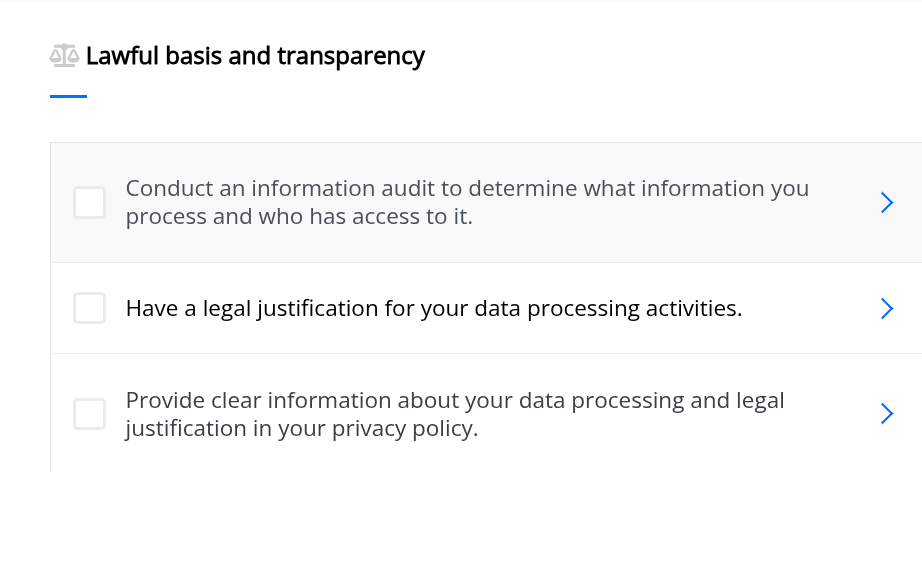

In [3]:
# Here is the prompt used

'''
You are an expert Python developer specializing in web scraping, data extraction, and reverse-engineering web workflows.

I need a robust Python script to scrape data from the following target URL:
# Let us select one policy document for now:
Target URL: https://gdpr.eu/checklist/

### Core Requirements:
1. **Target Data:** I specifically want to extract the only the checklist. Print it in the results, as points, use this symbol as the checkbox []
2. **Politeness & Rate Limiting:** The `robots.txt` file for this domain specifies a crawl delay. Please include a configurable crawl delay variable in the script. Set it to 1 second.
3. **Selector Accuracy:** To ensure the script works flawlessly, I have provided the raw `outerHTML` of the target element container below. Analyze its structure, tags, classes, or IDs to write highly precise CSS selectors or XPath expressions.

### Technical Stack Guidelines:
- Prefer using `requests` and `BeautifulSoup` if the content is rendered server-side.
- Include proper error handling, a realistic User-Agent header, and clean data export to a Pandas DataFrame.
- I am running the code on Google-Colab, so please be mindful of this.
- Make generous use of print statements at each step to indicate what is hapeening and to catch any errors.

### Target Element outerHTML:
Here are all the blocks which will be helpful to me
<div class="container">
                                    <div class="tab-checklist-box">
                                                    <div class="small-title">
                                <h5>
                                    <i class="fa fa-balance-scale"></i>                                                                                                                                                 Lawful basis and transparency                                </h5>
                            </div><!--/.small-title-->
                                                <div class="checklist-box">
                            <div class="tabnav tab-data">
                                <ul class="nav nav-tabs">
                                                                            <li class="nav-item">
                                            <a href="#tab-1-1" class="nav-link active" data-toggle="tab" role="tab">
                                                <em class="fa"></em>
                                                Conduct an information audit to determine what information you process and who has access to it.                                            </a>
                                        </li>
                                                                            <li class="nav-item">
                                            <a href="#tab-1-2" class="nav-link" data-toggle="tab" role="tab">
                                                <em class="fa"></em>
                                                Have a legal justification for your data processing activities.                                            </a>
                                        </li>
                                                                            <li class="nav-item">
                                            <a href="#tab-1-3" class="nav-link" data-toggle="tab" role="tab">
                                                <em class="fa"></em>
                                                Provide clear information about your data processing and legal justification in your privacy policy.                                            </a>
                                        </li>
                                                                    </ul><!--/.tabnav -->
                                <div class="tab-content" id="content-1">
                                                                                <div class="card tab-pane active show fade" role="tabpanel" id="tab-1-1">
                                                <div class="card-header" role="tab" id="heading-1-1">
                                                    <h5 class="mb-0">
                                                    	<em class="fa"></em>
                                                        <a class="collapsed" data-toggle="collapse" href="#collapse-1-1" data-parent="#content-1" aria-expanded="true" aria-controls="collapse-1-1">
                                                            Conduct an information audit to determine what information you process and who has access to it.                                                        </a>
                                                    </h5><!--/.mb-0-->
                                                </div><!--/.card-header-->
                                                <div id="collapse-1-1" class="collapse show" role="tabpanel" aria-labelledby="heading-1-1">
                                                    <div class="card-body"><p>Organizations that have at least 250 employees or conduct higher-risk data processing are required to keep an up-to-date and detailed <a href="https://gdpr.eu/article-30-records-of-processing-activities/">list of their processing activities</a> and be prepared to show that list to regulators upon request. The best way to demonstrate GDPR compliance is using a <a href="https://gdpr.eu/data-protection-impact-assessment-template/">data protection impact assessment</a> Organizations with fewer than 250 employees should also conduct an assessment because it will make complying with the GDPR's other requirements easier. In your list, you should include: the purposes of the processing, what kind of data you process, who has access to it in your organization, any third parties (and where they are located) that have access, what you're doing to protect the data (e.g. encryption), and when you plan to erase it (if possible).</p>
</div><!--/.card-body-->
                                                </div><!--/.collapse-->
                                            </div><!--/.collapse-->
                                                                                <div class="card tab-pane fade" role="tabpanel" id="tab-1-2">
                                                <div class="card-header" role="tab" id="heading-1-2">
                                                    <h5 class="mb-0">
                                                    	<em class="fa"></em>
                                                        <a data-toggle="collapse" href="#collapse-1-2" data-parent="#content-1" aria-expanded="false" aria-controls="collapse-1-2">
                                                            Have a legal justification for your data processing activities.                                                        </a>
                                                    </h5><!--/.mb-0-->
                                                </div><!--/.card-header-->
                                                <div id="collapse-1-2" class="collapse fade" role="tabpanel" aria-labelledby="heading-1-2">
                                                    <div class="card-body"><p>Processing of data is illegal under the GDPR unless you can justify it according to one of six conditions listed in <a href="https://gdpr.eu/article-6-how-to-process-personal-data-legally/">Article 6</a>. There are other provisions related to children and special categories of personal data in <a href="https://gdpr.eu/tag/chapter-2/">Articles 7-11</a>. Review these provisions, choose a lawful basis for processing, and document your rationale. Note that if you choose "consent" as your lawful basis, there are <a href="https://gdpr.eu/gdpr-consent-requirements/">extra obligations</a>, including giving data subjects the ongoing opportunity to revoke consent. If "legitimate interests" is your lawful basis, you must be able to demonstrate you have conducted a privacy impact assessment.</p>
</div><!--/.card-body-->
                                                </div><!--/.collapse-->
                                            </div><!--/.collapse-->
                                                                                <div class="card tab-pane fade" role="tabpanel" id="tab-1-3">
                                                <div class="card-header" role="tab" id="heading-1-3">
                                                    <h5 class="mb-0">
                                                    	<em class="fa"></em>
                                                        <a data-toggle="collapse" href="#collapse-1-3" data-parent="#content-1" aria-expanded="false" aria-controls="collapse-1-3">
                                                            Provide clear information about your data processing and legal justification in your privacy policy.                                                        </a>
                                                    </h5><!--/.mb-0-->
                                                </div><!--/.card-header-->
                                                <div id="collapse-1-3" class="collapse fade" role="tabpanel" aria-labelledby="heading-1-3">
                                                    <div class="card-body"><p>You need to tell people that you're collecting their data and why (<a href="https://gdpr.eu/article-12-how-controllers-should-provide-personal-data-to-the-subject/">Article 12</a>). You should explain how the data is processed, who has access to it, and how you're keeping it safe. This information should be included in your privacy policy and provided to data subjects at the time you collect their data. It must be presented "in a concise, transparent, intelligible and easily accessible form, using clear and plain language, in particular for any information addressed specifically to a child."</p>
</div><!--/.card-body-->
                                                </div><!--/.collapse-->
                                            </div><!--/.collapse-->
                                                                    </div><!--/.tab-container -->
                            </div><!--/.tab-data-->
                        </div><!--/.checklist-box-->
                    </div><!--/.tab-checklist-box-->
                                    <div class="tab-checklist-box">
                                                    <div class="small-title">
                                <h5>
                                                                        <i class="fa fa-database"></i>                                                                                                             Data security                                </h5>
                            </div><!--/.small-title-->
                                                <div class="checklist-box">
                            <div class="tabnav tab-data">
                                <ul class="nav nav-tabs">
                                                                            <li class="nav-item">
                                            <a href="#tab-2-1" class="nav-link active" data-toggle="tab" role="tab">
                                                <em class="fa"></em>
                                                Take data protection into account at all times, from the moment you begin developing a product to each time you process data.                                            </a>
                                        </li>
                                                                            <li class="nav-item">
                                            <a href="#tab-2-2" class="nav-link" data-toggle="tab" role="tab">
                                                <em class="fa"></em>
                                                Encrypt, pseudonymize, or anonymize personal data wherever possible.                                            </a>
                                        </li>
                                                                            <li class="nav-item">
                                            <a href="#tab-2-3" class="nav-link" data-toggle="tab" role="tab">
                                                <em class="fa"></em>
                                                Create an internal security policy for your team members, and build awareness about data protection.                                            </a>
                                        </li>
                                                                            <li class="nav-item">
                                            <a href="#tab-2-4" class="nav-link" data-toggle="tab" role="tab">
                                                <em class="fa"></em>
                                                Know when to conduct a data protection impact assessment, and have a process in place to carry it out.                                            </a>
                                        </li>
                                                                            <li class="nav-item">
                                            <a href="#tab-2-5" class="nav-link" data-toggle="tab" role="tab">
                                                <em class="fa"></em>
                                                Have a process in place to notify the authorities and your data subjects in the event of a data breach.                                            </a>
                                        </li>
                                                                    </ul><!--/.tabnav -->
                                <div class="tab-content" id="content-2">
                                                                                <div class="card tab-pane active show fade" role="tabpanel" id="tab-2-1">
                                                <div class="card-header" role="tab" id="heading-2-1">
                                                    <h5 class="mb-0">
                                                    	<em class="fa"></em>
                                                        <a class="collapsed" data-toggle="collapse" href="#collapse-2-1" data-parent="#content-2" aria-expanded="true" aria-controls="collapse-2-1">
                                                            Take data protection into account at all times, from the moment you begin developing a product to each time you process data.                                                        </a>
                                                    </h5><!--/.mb-0-->
                                                </div><!--/.card-header-->
                                                <div id="collapse-2-1" class="collapse show" role="tabpanel" aria-labelledby="heading-2-1">
                                                    <div class="card-body"><p>You must follow the principles of "<a href="https://gdpr.eu/article-25-data-protection-by-design/">data protection by design and by default</a>," including implementing "appropriate technical and organizational measures" to protect data. In other words, data protection is something you now have to consider whenever you do anything with other people's personal data. You also need to make sure any processing of personal data adheres to the data protection principles outlined in <a href="https://gdpr.eu/article-5-how-to-process-personal-data/">Article 5</a>. Technical measures include encryption, and organizational measures are things like limiting the amount of personal data you collect or deleting data you no longer need. The point is that it needs to be something you and your employees are always aware of.</p>
</div><!--/.card-body-->
                                                </div><!--/.collapse-->
                                            </div><!--/.collapse-->
                                                                                <div class="card tab-pane fade" role="tabpanel" id="tab-2-2">
                                                <div class="card-header" role="tab" id="heading-2-2">
                                                    <h5 class="mb-0">
                                                    	<em class="fa"></em>
                                                        <a data-toggle="collapse" href="#collapse-2-2" data-parent="#content-2" aria-expanded="false" aria-controls="collapse-2-2">
                                                            Encrypt, pseudonymize, or anonymize personal data wherever possible.                                                        </a>
                                                    </h5><!--/.mb-0-->
                                                </div><!--/.card-header-->
                                                <div id="collapse-2-2" class="collapse fade" role="tabpanel" aria-labelledby="heading-2-2">
                                                    <div class="card-body"><p>Most of the productivity tools used by businesses are now available with <a href="https://protonmail.com">end-to-end encryption</a> built in, including email, messaging, notes, and cloud storage. The GDPR requires organizations to <a href="https://gdpr.eu/article-32-security-of-processing/">use encryption or pseudeonymization</a> whenever feasible. </p>
</div><!--/.card-body-->
                                                </div><!--/.collapse-->
                                            </div><!--/.collapse-->
                                                                                <div class="card tab-pane fade" role="tabpanel" id="tab-2-3">
                                                <div class="card-header" role="tab" id="heading-2-3">
                                                    <h5 class="mb-0">
                                                    	<em class="fa"></em>
                                                        <a data-toggle="collapse" href="#collapse-2-3" data-parent="#content-2" aria-expanded="false" aria-controls="collapse-2-3">
                                                            Create an internal security policy for your team members, and build awareness about data protection.                                                        </a>
                                                    </h5><!--/.mb-0-->
                                                </div><!--/.card-header-->
                                                <div id="collapse-2-3" class="collapse fade" role="tabpanel" aria-labelledby="heading-2-3">
                                                    <div class="card-body"><p>Even if your technical security is strong, <a href="https://gdpr.eu/recital-78-appropriate-technical-and-organisational-measures/">operational security</a> can still be a weak link. Create a security policy that ensures your team members are knowledgeable about data security. It should include guidance about email security, passwords, two-factor authentication, device encryption, and <a href="https://protonvpn.com">VPNs</a>. Employees who have access to personal data and non-technical employees should receive extra training in the requirements of the GDPR.</p>
</div><!--/.card-body-->
                                                </div><!--/.collapse-->
                                            </div><!--/.collapse-->
                                                                                <div class="card tab-pane fade" role="tabpanel" id="tab-2-4">
                                                <div class="card-header" role="tab" id="heading-2-4">
                                                    <h5 class="mb-0">
                                                    	<em class="fa"></em>
                                                        <a data-toggle="collapse" href="#collapse-2-4" data-parent="#content-2" aria-expanded="false" aria-controls="collapse-2-4">
                                                            Know when to conduct a data protection impact assessment, and have a process in place to carry it out.                                                        </a>
                                                    </h5><!--/.mb-0-->
                                                </div><!--/.card-header-->
                                                <div id="collapse-2-4" class="collapse fade" role="tabpanel" aria-labelledby="heading-2-4">
                                                    <div class="card-body"><p>A <a href="https://gdpr.eu/article-35-impact-assessment/">data protection impact assessment</a> (aka privacy impact assessment) is a way to help you understand how your product or service could jeopardize your customers' data, as well as how to minimize those risks. The UK Information Commissioner's Office (ICO) has a data protection impact assessment checklist on its website. The GDPR requires organizations to carry out this kind of analysis whenever they plan to use people's data in such a way that it's "likely to result in a high risk to [their] rights and freedoms." The ICO recommends just doing it anytime you're about to process personal data.</p>
</div><!--/.card-body-->
                                                </div><!--/.collapse-->
                                            </div><!--/.collapse-->
                                                                                <div class="card tab-pane fade" role="tabpanel" id="tab-2-5">
                                                <div class="card-header" role="tab" id="heading-2-5">
                                                    <h5 class="mb-0">
                                                    	<em class="fa"></em>
                                                        <a data-toggle="collapse" href="#collapse-2-5" data-parent="#content-2" aria-expanded="false" aria-controls="collapse-2-5">
                                                            Have a process in place to notify the authorities and your data subjects in the event of a data breach.                                                        </a>
                                                    </h5><!--/.mb-0-->
                                                </div><!--/.card-header-->
                                                <div id="collapse-2-5" class="collapse fade" role="tabpanel" aria-labelledby="heading-2-5">
                                                    <div class="card-body"><p>If there's a data breach and personal data is exposed, you are required to <a href="https://gdpr.eu/article-33-notification-of-a-personal-data-breach/">notify the supervisory authority</a> in your jurisdiction within 72 hours. A list of many of the EU member states supervisory authorities can be found here. The GDPR does not specify whom you should notify if you are not an EU-based organization. For those in English-speaking non-EU countries, you may find it easiest to notify the Office of the Data Protection Commissioner in Ireland. You are also required to quickly <a href="https://gdpr.eu/article-34-communication-of-a-personal-data-breach/">communicate data breaches to your data subjects</a> unless the breach is unlikely to put them at risk (for instance, if the stolen data is encrypted).</p>
</div><!--/.card-body-->
                                                </div><!--/.collapse-->
                                            </div><!--/.collapse-->
                                                                    </div><!--/.tab-container -->
                            </div><!--/.tab-data-->
                        </div><!--/.checklist-box-->
                    </div><!--/.tab-checklist-box-->
                                    <div class="tab-checklist-box">
                                                    <div class="small-title">
                                <h5>
                                                                                                            <i class="fa fa-paperclip"></i>                                                                         Accountability and governance                                </h5>
                            </div><!--/.small-title-->
                                                <div class="checklist-box">
                            <div class="tabnav tab-data">
                                <ul class="nav nav-tabs">
                                                                            <li class="nav-item">
                                            <a href="#tab-3-1" class="nav-link active" data-toggle="tab" role="tab">
                                                <em class="fa"></em>
                                                Designate someone responsible for ensuring GDPR compliance across your organization.                                            </a>
                                        </li>
                                                                            <li class="nav-item">
                                            <a href="#tab-3-2" class="nav-link" data-toggle="tab" role="tab">
                                                <em class="fa"></em>
                                                Sign a data processing agreement between your organization and any third parties that process personal data on your behalf.                                            </a>
                                        </li>
                                                                            <li class="nav-item">
                                            <a href="#tab-3-3" class="nav-link" data-toggle="tab" role="tab">
                                                <em class="fa"></em>
                                                If your organization is outside the EU, appoint a representative within one of the EU member states.                                            </a>
                                        </li>
                                                                            <li class="nav-item">
                                            <a href="#tab-3-4" class="nav-link" data-toggle="tab" role="tab">
                                                <em class="fa"></em>
                                                Appoint a Data Protection Officer (if necessary)                                            </a>
                                        </li>
                                                                    </ul><!--/.tabnav -->
                                <div class="tab-content" id="content-3">
                                                                                <div class="card tab-pane active show fade" role="tabpanel" id="tab-3-1">
                                                <div class="card-header" role="tab" id="heading-3-1">
                                                    <h5 class="mb-0">
                                                    	<em class="fa"></em>
                                                        <a class="collapsed" data-toggle="collapse" href="#collapse-3-1" data-parent="#content-3" aria-expanded="true" aria-controls="collapse-3-1">
                                                            Designate someone responsible for ensuring GDPR compliance across your organization.                                                        </a>
                                                    </h5><!--/.mb-0-->
                                                </div><!--/.card-header-->
                                                <div id="collapse-3-1" class="collapse show" role="tabpanel" aria-labelledby="heading-3-1">
                                                    <div class="card-body"><p>Another part of "<a href="https://gdpr.eu/article-25-data-protection-by-design/">data protection by design and by default</a>" is making sure someone in your organization is accountable for GDPR compliance. This person should be empowered to evaluate data protection policies and the implementation of those policies.</p>
</div><!--/.card-body-->
                                                </div><!--/.collapse-->
                                            </div><!--/.collapse-->
                                                                                <div class="card tab-pane fade" role="tabpanel" id="tab-3-2">
                                                <div class="card-header" role="tab" id="heading-3-2">
                                                    <h5 class="mb-0">
                                                    	<em class="fa"></em>
                                                        <a data-toggle="collapse" href="#collapse-3-2" data-parent="#content-3" aria-expanded="false" aria-controls="collapse-3-2">
                                                            Sign a data processing agreement between your organization and any third parties that process personal data on your behalf.                                                        </a>
                                                    </h5><!--/.mb-0-->
                                                </div><!--/.card-header-->
                                                <div id="collapse-3-2" class="collapse fade" role="tabpanel" aria-labelledby="heading-3-2">
                                                    <div class="card-body"><p>This includes any third-party services that handle the personal data of your data subjects, including analytics software, email services, cloud servers, etc. The vast majority of services have a standard <a href="https://gdpr.eu/data-processing-agreement/">data processing agreement</a> available on their websites for you to review. They spell out the rights and obligations of each party for GDPR compliance. You should only use third parties that are reliable and can make sufficient data protection guarantees.</p>
</div><!--/.card-body-->
                                                </div><!--/.collapse-->
                                            </div><!--/.collapse-->
                                                                                <div class="card tab-pane fade" role="tabpanel" id="tab-3-3">
                                                <div class="card-header" role="tab" id="heading-3-3">
                                                    <h5 class="mb-0">
                                                    	<em class="fa"></em>
                                                        <a data-toggle="collapse" href="#collapse-3-3" data-parent="#content-3" aria-expanded="false" aria-controls="collapse-3-3">
                                                            If your organization is outside the EU, appoint a representative within one of the EU member states.                                                        </a>
                                                    </h5><!--/.mb-0-->
                                                </div><!--/.card-header-->
                                                <div id="collapse-3-3" class="collapse fade" role="tabpanel" aria-labelledby="heading-3-3">
                                                    <div class="card-body"><p>If you process data relating to people in one particular member state, you need to <a href="https://gdpr.eu/article-27-representatives-of-controllers-not-in-union/">appoint a representative</a> in that country who can communicate on your behalf with data protection authorities. The GDPR and its official supporting documents do not give guidance for situations where processing affects EU individuals across multiple member states. Until this requirement is interpreted, it may be prudent to designate a representative in a member state that uses your language. Some organizations, like public bodies, are not required to appoint a representative in the EU. </p>
</div><!--/.card-body-->
                                                </div><!--/.collapse-->
                                            </div><!--/.collapse-->
                                                                                <div class="card tab-pane fade" role="tabpanel" id="tab-3-4">
                                                <div class="card-header" role="tab" id="heading-3-4">
                                                    <h5 class="mb-0">
                                                    	<em class="fa"></em>
                                                        <a data-toggle="collapse" href="#collapse-3-4" data-parent="#content-3" aria-expanded="false" aria-controls="collapse-3-4">
                                                            Appoint a Data Protection Officer (if necessary)                                                        </a>
                                                    </h5><!--/.mb-0-->
                                                </div><!--/.card-header-->
                                                <div id="collapse-3-4" class="collapse fade" role="tabpanel" aria-labelledby="heading-3-4">
                                                    <div class="card-body"><p>There are three circumstances in which organizations are required to have a <a href="https://gdpr.eu/data-protection-officer/">Data Protection Officer</a> (DPO), but it's not a bad idea to have one even if the rule doesn't apply to you. The DPO should be an expert on data protection whose job is to monitor GDPR compliance, assess data protection risks, advise on data protection impact assessments, and cooperate with regulators. </p>
</div><!--/.card-body-->
                                                </div><!--/.collapse-->
                                            </div><!--/.collapse-->
                                                                    </div><!--/.tab-container -->
                            </div><!--/.tab-data-->
                        </div><!--/.checklist-box-->
                    </div><!--/.tab-checklist-box-->
                                    <div class="tab-checklist-box">
                                                    <div class="small-title">
                                <h5>
                                                                                                                                                <i class="fa fa-eye"></i>                                     Privacy rights                                </h5>
                            </div><!--/.small-title-->
                                                <div class="checklist-box">
                            <div class="tabnav tab-data">
                                <ul class="nav nav-tabs">
                                                                            <li class="nav-item">
                                            <a href="#tab-4-1" class="nav-link active" data-toggle="tab" role="tab">
                                                <em class="fa"></em>
                                                It's easy for your customers to request and receive all the information you have about them.                                            </a>
                                        </li>
                                                                            <li class="nav-item">
                                            <a href="#tab-4-2" class="nav-link" data-toggle="tab" role="tab">
                                                <em class="fa"></em>
                                                It's easy for your customers to correct or update inaccurate or incomplete information.                                            </a>
                                        </li>
                                                                            <li class="nav-item">
                                            <a href="#tab-4-3" class="nav-link" data-toggle="tab" role="tab">
                                                <em class="fa"></em>
                                                It's easy for your customers to request to have their personal data deleted.                                             </a>
                                        </li>
                                                                            <li class="nav-item">
                                            <a href="#tab-4-4" class="nav-link" data-toggle="tab" role="tab">
                                                <em class="fa"></em>
                                                It's easy for your customers to ask you to stop processing their data.                                             </a>
                                        </li>
                                                                            <li class="nav-item">
                                            <a href="#tab-4-5" class="nav-link" data-toggle="tab" role="tab">
                                                <em class="fa"></em>
                                                It's easy for your customers to receive a copy of their personal data in a format that can be easily transferred to another company.                                            </a>
                                        </li>
                                                                            <li class="nav-item">
                                            <a href="#tab-4-6" class="nav-link" data-toggle="tab" role="tab">
                                                <em class="fa"></em>
                                                It's easy for your customers to object to you processing their data.                                            </a>
                                        </li>
                                                                            <li class="nav-item">
                                            <a href="#tab-4-7" class="nav-link" data-toggle="tab" role="tab">
                                                <em class="fa"></em>
                                                If you make decisions about people based on automated processes, you have a procedure to protect their rights.                                            </a>
                                        </li>
                                                                    </ul><!--/.tabnav -->
                                <div class="tab-content" id="content-4">
                                                                                <div class="card tab-pane active show fade" role="tabpanel" id="tab-4-1">
                                                <div class="card-header" role="tab" id="heading-4-1">
                                                    <h5 class="mb-0">
                                                    	<em class="fa"></em>
                                                        <a class="collapsed" data-toggle="collapse" href="#collapse-4-1" data-parent="#content-4" aria-expanded="true" aria-controls="collapse-4-1">
                                                            It's easy for your customers to request and receive all the information you have about them.                                                        </a>
                                                    </h5><!--/.mb-0-->
                                                </div><!--/.card-header-->
                                                <div id="collapse-4-1" class="collapse show" role="tabpanel" aria-labelledby="heading-4-1">
                                                    <div class="card-body"><p>People have the <a href="https://gdpr.eu/article-15-right-of-access/">right to see what personal data you have about them</a> and how you're using it. They also have a right to know how long you plan to store their information and the reason for keeping it that length of time. You have to send them the first copy of this information for free but can charge a reasonable fee for subsequent copies. Make sure you can verify the identity of the person requesting the data. You should be able to comply with such requests within a month.</p>
</div><!--/.card-body-->
                                                </div><!--/.collapse-->
                                            </div><!--/.collapse-->
                                                                                <div class="card tab-pane fade" role="tabpanel" id="tab-4-2">
                                                <div class="card-header" role="tab" id="heading-4-2">
                                                    <h5 class="mb-0">
                                                    	<em class="fa"></em>
                                                        <a data-toggle="collapse" href="#collapse-4-2" data-parent="#content-4" aria-expanded="false" aria-controls="collapse-4-2">
                                                            It's easy for your customers to correct or update inaccurate or incomplete information.                                                        </a>
                                                    </h5><!--/.mb-0-->
                                                </div><!--/.card-header-->
                                                <div id="collapse-4-2" class="collapse fade" role="tabpanel" aria-labelledby="heading-4-2">
                                                    <div class="card-body"><p>Do your best to keep data up to date by putting a data quality process in place, and make it easy for your customers to view (<a href="https://gdpr.eu/article-15-right-of-access/">Article 15</a>) and update their personal information for accuracy and completeness. Make sure you can verify the identity of the person requesting the data. You should be able to comply with requests under <a href="https://gdpr.eu/article-16-right-to-rectification/">Article 16</a> within a month.</p>
</div><!--/.card-body-->
                                                </div><!--/.collapse-->
                                            </div><!--/.collapse-->
                                                                                <div class="card tab-pane fade" role="tabpanel" id="tab-4-3">
                                                <div class="card-header" role="tab" id="heading-4-3">
                                                    <h5 class="mb-0">
                                                    	<em class="fa"></em>
                                                        <a data-toggle="collapse" href="#collapse-4-3" data-parent="#content-4" aria-expanded="false" aria-controls="collapse-4-3">
                                                            It's easy for your customers to request to have their personal data deleted.                                                         </a>
                                                    </h5><!--/.mb-0-->
                                                </div><!--/.card-header-->
                                                <div id="collapse-4-3" class="collapse fade" role="tabpanel" aria-labelledby="heading-4-3">
                                                    <div class="card-body"><p>People generally have the <a href="https://gdpr.eu/right-to-be-forgotten/">right to ask you to delete</a> all the personal data you have about them, and you have to honor their request within about a month. There are a five grounds on which you can deny the request, such as the exercise of freedom of speech or compliance with a legal obligation. You must also try to verify the identity of the person making the request.</p>
</div><!--/.card-body-->
                                                </div><!--/.collapse-->
                                            </div><!--/.collapse-->
                                                                                <div class="card tab-pane fade" role="tabpanel" id="tab-4-4">
                                                <div class="card-header" role="tab" id="heading-4-4">
                                                    <h5 class="mb-0">
                                                    	<em class="fa"></em>
                                                        <a data-toggle="collapse" href="#collapse-4-4" data-parent="#content-4" aria-expanded="false" aria-controls="collapse-4-4">
                                                            It's easy for your customers to ask you to stop processing their data.                                                         </a>
                                                    </h5><!--/.mb-0-->
                                                </div><!--/.card-header-->
                                                <div id="collapse-4-4" class="collapse fade" role="tabpanel" aria-labelledby="heading-4-4">
                                                    <div class="card-body"><p>Your data subjects can request to <a href="https://gdpr.eu/article-18-right-to-restriction-of-processing/">restrict or stop processing of their data</a> if certain grounds apply, mainly if there's some dispute about the lawfulness of the processing or the accuracy of the data. You are required to honor their request within about a month. While processing is restricted, you're still allowed to keep storing their data. You must notify the data subject before you begin processing their data again.</p>
</div><!--/.card-body-->
                                                </div><!--/.collapse-->
                                            </div><!--/.collapse-->
                                                                                <div class="card tab-pane fade" role="tabpanel" id="tab-4-5">
                                                <div class="card-header" role="tab" id="heading-4-5">
                                                    <h5 class="mb-0">
                                                    	<em class="fa"></em>
                                                        <a data-toggle="collapse" href="#collapse-4-5" data-parent="#content-4" aria-expanded="false" aria-controls="collapse-4-5">
                                                            It's easy for your customers to receive a copy of their personal data in a format that can be easily transferred to another company.                                                        </a>
                                                    </h5><!--/.mb-0-->
                                                </div><!--/.card-header-->
                                                <div id="collapse-4-5" class="collapse fade" role="tabpanel" aria-labelledby="heading-4-5">
                                                    <div class="card-body"><p>This means that you should be able to <a href="https://gdpr.eu/article-20-right-to-data-portability/">send their personal data</a> in a commonly readable format (e.g. a spreadsheet) either to them or to a third party they designate. This may seem unfair from a business standpoint in that you may have to turn over your customers' data to a competitor. But from privacy standpoint, the idea is that people own their data, not you.</p>
</div><!--/.card-body-->
                                                </div><!--/.collapse-->
                                            </div><!--/.collapse-->
                                                                                <div class="card tab-pane fade" role="tabpanel" id="tab-4-6">
                                                <div class="card-header" role="tab" id="heading-4-6">
                                                    <h5 class="mb-0">
                                                    	<em class="fa"></em>
                                                        <a data-toggle="collapse" href="#collapse-4-6" data-parent="#content-4" aria-expanded="false" aria-controls="collapse-4-6">
                                                            It's easy for your customers to object to you processing their data.                                                        </a>
                                                    </h5><!--/.mb-0-->
                                                </div><!--/.card-header-->
                                                <div id="collapse-4-6" class="collapse fade" role="tabpanel" aria-labelledby="heading-4-6">
                                                    <div class="card-body"><p>If you're processing their data for the purposes of direct marketing, you have to <a href="https://gdpr.eu/article-21-right-to-object/">stop processing it immediately</a> for that purpose. Otherwise, you may be able to challenge their objection if you can demonstrate "compelling legitimate grounds." </p>
</div><!--/.card-body-->
                                                </div><!--/.collapse-->
                                            </div><!--/.collapse-->
                                                                                <div class="card tab-pane fade" role="tabpanel" id="tab-4-7">
                                                <div class="card-header" role="tab" id="heading-4-7">
                                                    <h5 class="mb-0">
                                                    	<em class="fa"></em>
                                                        <a data-toggle="collapse" href="#collapse-4-7" data-parent="#content-4" aria-expanded="false" aria-controls="collapse-4-7">
                                                            If you make decisions about people based on automated processes, you have a procedure to protect their rights.                                                        </a>
                                                    </h5><!--/.mb-0-->
                                                </div><!--/.card-header-->
                                                <div id="collapse-4-7" class="collapse fade" role="tabpanel" aria-labelledby="heading-4-7">
                                                    <div class="card-body"><p>Some types of organizations use <a href="https://gdpr.eu/article-22-automated-individual-decision-making/">automated processes</a> to help them make decisions about people that have legal or "similarly significant" effects. If you think that applies to you, you'll need to set up a procedure to ensure you are protecting their rights, freedoms, and legitimate interests. You need to make it easy for people to request human intervention, to weigh in on decisions, and to challenge decisions you've already made.</p>
</div><!--/.card-body-->
                                                </div><!--/.collapse-->
                                            </div><!--/.collapse-->
                                                                    </div><!--/.tab-container -->
                            </div><!--/.tab-data-->
                        </div><!--/.checklist-box-->
                    </div><!--/.tab-checklist-box-->
                            </div>


If there are any questions, please ask them before generating the code.
'''

import requests
from bs4 import BeautifulSoup
import pandas as pd
import time

def scrape_gdpr_checklist(url="https://gdpr.eu/checklist/"):
    # Configurable crawl delay variable
    CRAWL_DELAY = 1

    # Realistic User-Agent header
    headers = {
        "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36"
    }

    print(f"--> Initiating GET request to: {url}")
    try:
        response = requests.get(url, headers=headers, timeout=10)
        response.raise_for_status()
        print(f"--> Request successful! Status Code: {response.status_code}")
    except requests.exceptions.HTTPError as http_err:
        print(f"--> HTTP Error occurred: {http_err}")
        return None
    except Exception as err:
        print(f"--> An error occurred: {err}")
        return None

    print(f"--> Observing crawl delay of {CRAWL_DELAY} second(s) to respect domain limits...")
    time.sleep(CRAWL_DELAY)

    print("--> Parsing HTML content with BeautifulSoup...")
    soup = BeautifulSoup(response.text, 'html.parser')

    print("--> Locating checklist elements using CSS selectors...")
    # Target the link texts inside the nav-tabs which hold the checklist items
    nav_items = soup.select('.tab-checklist-box .nav-item .nav-link')

    if not nav_items:
         print("--> Warning: No items found. Verify if the target HTML structure has changed.")
         return None

    print(f"--> Successfully found {len(nav_items)} checklist elements. Extracting text...\n")

    checklist_data = []

    print("================ EXTRACTED CHECKLIST ================")
    for item in nav_items:
        # get_text(strip=True) cleans up the whitespace and ignores empty child elements like <em class="fa">
        item_text = item.get_text(strip=True)

        if item_text:
            checklist_data.append(item_text)
            # Outputting the requested format
            print(f"[] {item_text}")
    print("=====================================================\n")

    print("--> Structuring data into a Pandas DataFrame...")
    df = pd.DataFrame(checklist_data, columns=["GDPR Checklist Requirement"])

    print("--> Execution complete. Returning DataFrame.")
    return df

# Execute the scraper
gdpr_dataframe = scrape_gdpr_checklist()

# Using Colab's native display function for a clean table output
if gdpr_dataframe is not None:
    display(gdpr_dataframe)

--> Initiating GET request to: https://gdpr.eu/checklist/
--> Request successful! Status Code: 200
--> Observing crawl delay of 1 second(s) to respect domain limits...
--> Parsing HTML content with BeautifulSoup...
--> Locating checklist elements using CSS selectors...
--> Successfully found 19 checklist elements. Extracting text...

================ EXTRACTED CHECKLIST ================
[] Conduct an information audit to determine what information you process and who has access to it.
[] Have a legal justification for your data processing activities.
[] Provide clear information about your data processing and legal justification in your privacy policy.
[] Take data protection into account at all times, from the moment you begin developing a product to each time you process data.
[] Encrypt, pseudonymize, or anonymize personal data wherever possible.
[] Create an internal security policy for your team members, and build awareness about data protection.
[] Know when to conduct a data pro

,GDPR Checklist Requirement
0,Conduct an information audit to determine what...
1,Have a legal justification for your data proce...
2,Provide clear information about your data proc...
3,Take data protection into account at all times...
4,"Encrypt, pseudonymize, or anonymize personal d..."
5,Create an internal security policy for your te...
6,Know when to conduct a data protection impact ...
7,Have a process in place to notify the authorit...
8,Designate someone responsible for ensuring GDP...
9,Sign a data processing agreement between your ...


### Complex Example: EU-Lex, example policy page: Few shot prompt

In [5]:
# Here is the prompt used

'''
You are an expert Python developer specializing in web scraping, data extraction, and reverse-engineering web workflows.

I need a robust Python script to scrape data from the following target URL:
# Let us select one policy document for now:
Target URL: https://eur-lex.europa.eu/legal-content/EN/TXT/HTML/?uri=CELEX:32024R1689

### Core Requirements:
1. **Target Data:** I specifically want to extract the main results including document titles, dates, and links, but do not limit the script strictly to the table if there is valuable metadata associated with each row.
2. **Politeness & Rate Limiting:** The `robots.txt` file for this domain specifies a crawl delay. Please include a configurable crawl delay variable in the script. Set it to 10 seconds based on the site's guidelines.
3. **Selector Accuracy:** To ensure the script works flawlessly, I have provided the raw `outerHTML` of the target element container below. Analyze its structure, tags, classes, or IDs to write highly precise CSS selectors or XPath expressions.

### Technical Stack Guidelines:
- Prefer using `requests` and `BeautifulSoup` if the content is rendered server-side.
- Include proper error handling, a realistic User-Agent header, and clean data export to a Pandas DataFrame.
- I am running the code on Google-Colab, so please be mindful of this.
- Make generous use of print statements at each step to indicate what is hapeening and to catch any errors.

### Target Element outerHTML:
Here are all the blocks which will be helpful to me
1. <p class="oj-hd-uniq">2024/1689</p>: some sort of heading/number
2. <div class="eli-main-title" id="tit_1">
            <p class="oj-doc-ti" id="d1e39-1-1">
            REGULATION (EU) 2024/1689 OF THE EUROPEAN PARLIAMENT AND OF THE COUNCIL
         </p>
            <p class="oj-doc-ti">of 13&nbsp;June 2024
         </p>
            <p class="oj-doc-ti">laying down harmonised rules on artificial intelligence and amending Regulations (EC) No&nbsp;300/2008, (EU) No&nbsp;167/2013, (EU) No&nbsp;168/2013, (EU) 2018/858, (EU) 2018/1139 and (EU) 2019/2144 and Directives 2014/90/EU, (EU) 2016/797 and (EU) 2020/1828 (Artificial Intelligence Act)</p>
            <p class="oj-doc-ti">(Text with EEA relevance)</p>
         </div>
3. Most of the text is stored here,oj-normal:
<p class="oj-normal">Having regard to the Treaty on the Functioning of the European Union, and in particular Articles&nbsp;16 and&nbsp;114 thereof,</p>
4. Sometimes there are these elements too:
<div class="eli-subdivision" id="art_113">
                  <p id="d1e9151-1-1" class="oj-ti-art">Article&nbsp;113</p>
                  <div class="eli-title" id="art_113.tit_1">
                     <p class="oj-sti-art">Entry into force and application</p>
                  </div>
                  <p class="oj-normal">This Regulation shall enter into force on the twentieth day following that of its publication in the <span class="oj-italic">Official Journal of the European Union</span>.</p>
                  <p class="oj-normal">It shall apply from 2&nbsp;August 2026.</p>
                  <p class="oj-normal">However:</p>
                  <table width="100%" border="0" cellspacing="0" cellpadding="0">
                     <colgroup><col width="4%">
                     <col width="96%">
                     </colgroup><tbody>
                        <tr>
                           <td valign="top">
                              <p class="oj-normal">(a)</p>
                           </td>
                           <td valign="top">
                              <p class="oj-normal">Chapters&nbsp;I&nbsp;and II shall apply from 2&nbsp;February 2025;</p>
                           </td>
                        </tr>
                     </tbody>
                  </table>
                  <table width="100%" border="0" cellspacing="0" cellpadding="0">
                     <colgroup><col width="4%">
                     <col width="96%">
                     </colgroup><tbody>
                        <tr>
                           <td valign="top">
                              <p class="oj-normal">(b)</p>
                           </td>
                           <td valign="top">
                              <p class="oj-normal">Chapter&nbsp;III Section&nbsp;4, Chapter&nbsp;V, Chapter&nbsp;VII and Chapter&nbsp;XII and Article&nbsp;78 shall apply from 2&nbsp;August 2025, with the exception of Article&nbsp;101;</p>
                           </td>
                        </tr>
                     </tbody>
                  </table>
                  <table width="100%" border="0" cellspacing="0" cellpadding="0">
                     <colgroup><col width="4%">
                     <col width="96%">
                     </colgroup><tbody>
                        <tr>
                           <td valign="top">
                              <p class="oj-normal">(c)</p>
                           </td>
                           <td valign="top">
                              <p class="oj-normal">Article&nbsp;6(1) and the corresponding obligations in this Regulation shall apply from 2&nbsp;August 2027.</p>
                           </td>
                        </tr>
                     </tbody>
                  </table>
               </div>
5. And also these:
<div class="eli-container" id="anx_I">
            <p class="oj-doc-ti" id="d1e38-124-1">ANNEX&nbsp;I</p>
            <p class="oj-doc-ti">List of Union harmonisation legislation</p>
            <p id="d1e47-124-1" class="oj-ti-grseq-1">Section A. List of Union harmonisation legislation based on the New Legislative Framework</p>
            <table width="100%" border="0" cellspacing="0" cellpadding="0">
               <colgroup><col width="4%">
               <col width="4%">
               <col width="92%">
               </colgroup><tbody>
                  <tr>
                     <td valign="top">
                     </td><td valign="top">
                        <p class="oj-normal">1.</p>
                     </td>
                     <td valign="top">
                        <span>Directive 2006/42/EC of the European Parliament and of the Council of 17&nbsp;May 2006 on machinery, and amending Directive 95/16/EC (<a href="./../../../../legal-content/EN/AUTO/?uri=OJ:L:2006:157:TOC">OJ L&nbsp;157, 9.6.2006, p.&nbsp;24</a>);</span>
                     </td>
                  </tr>
               </tbody>
            </table>
            <table width="100%" border="0" cellspacing="0" cellpadding="0">
               <colgroup><col width="4%">
               <col width="4%">
               <col width="92%">
               </colgroup><tbody>
                  <tr>
                     <td valign="top">
                     </td><td valign="top">
                        <p class="oj-normal">2.</p>
                     </td>
                     <td valign="top">
                        <span>Directive 2009/48/EC of the European Parliament and of the Council of 18&nbsp;June 2009 on the safety of toys (<a href="./../../../../legal-content/EN/AUTO/?uri=OJ:L:2009:170:TOC">OJ L&nbsp;170, 30.6.2009, p.&nbsp;1</a>);</span>
                     </td>
                  </tr>
               </tbody>
            </table>
            <table width="100%" border="0" cellspacing="0" cellpadding="0">
               <colgroup><col width="4%">
               <col width="4%">
               <col width="92%">
               </colgroup><tbody>
                  <tr>
                     <td valign="top">
                     </td><td valign="top">
                        <p class="oj-normal">3.</p>
                     </td>
                     <td valign="top">
                        <span>Directive 2013/53/EU of the European Parliament and of the Council of&nbsp;20&nbsp;November 2013 on recreational craft and personal watercraft and repealing Directive&nbsp;94/25/EC (<a href="./../../../../legal-content/EN/AUTO/?uri=OJ:L:2013:354:TOC">OJ L&nbsp;354, 28.12.2013, p.&nbsp;90</a>);</span>
                     </td>
                  </tr>
               </tbody>
            </table>
            <table width="100%" border="0" cellspacing="0" cellpadding="0">
               <colgroup><col width="4%">
               <col width="4%">
               <col width="92%">
               </colgroup><tbody>
                  <tr>
                     <td valign="top">
                     </td><td valign="top">
                        <p class="oj-normal">4.</p>
                     </td>
                     <td valign="top">
                        <span>Directive 2014/33/EU of the European Parliament and of the Council of 26&nbsp;February 2014 on the harmonisation of the laws of the Member States relating to lifts and safety components for lifts (<a href="./../../../../legal-content/EN/AUTO/?uri=OJ:L:2014:096:TOC">OJ L&nbsp;96, 29.3.2014, p.&nbsp;251</a>);</span>
                     </td>
                  </tr>
               </tbody>
            </table>
            <table width="100%" border="0" cellspacing="0" cellpadding="0">
               <colgroup><col width="4%">
               <col width="4%">
               <col width="92%">
               </colgroup><tbody>
                  <tr>
                     <td valign="top">
                     </td><td valign="top">
                        <p class="oj-normal">5.</p>
                     </td>
                     <td valign="top">
                        <span>Directive 2014/34/EU of the European Parliament and of the Council of 26&nbsp;February 2014 on the harmonisation of the laws of the Member States relating to equipment and protective systems intended for use in potentially explosive atmospheres (<a href="./../../../../legal-content/EN/AUTO/?uri=OJ:L:2014:096:TOC">OJ L&nbsp;96, 29.3.2014, p.&nbsp;309</a>);</span>
                     </td>
                  </tr>
               </tbody>
            </table>
            <table width="100%" border="0" cellspacing="0" cellpadding="0">
               <colgroup><col width="4%">
               <col width="4%">
               <col width="92%">
               </colgroup><tbody>
                  <tr>
                     <td valign="top">
                     </td><td valign="top">
                        <p class="oj-normal">6.</p>
                     </td>
                     <td valign="top">
                        <span>Directive 2014/53/EU of the European Parliament and of the Council of 16&nbsp;April 2014 on the harmonisation of the laws of the Member States relating to the making available on the market of radio equipment and repealing Directive 1999/5/EC (<a href="./../../../../legal-content/EN/AUTO/?uri=OJ:L:2014:153:TOC">OJ L&nbsp;153, 22.5.2014, p.&nbsp;62</a>);</span>
                     </td>
                  </tr>
               </tbody>
            </table>
            <table width="100%" border="0" cellspacing="0" cellpadding="0">
               <colgroup><col width="4%">
               <col width="4%">
               <col width="92%">
               </colgroup><tbody>
                  <tr>
                     <td valign="top">
                     </td><td valign="top">
                        <p class="oj-normal">7.</p>
                     </td>
                     <td valign="top">
                        <span>Directive 2014/68/EU of the European Parliament and of the Council of 15&nbsp;May 2014 on the harmonisation of the laws of the Member States relating to the making available on the market of pressure equipment (<a href="./../../../../legal-content/EN/AUTO/?uri=OJ:L:2014:189:TOC">OJ L&nbsp;189, 27.6.2014, p.&nbsp;164</a>);</span>
                     </td>
                  </tr>
               </tbody>
            </table>
            <table width="100%" border="0" cellspacing="0" cellpadding="0">
               <colgroup><col width="4%">
               <col width="4%">
               <col width="92%">
               </colgroup><tbody>
                  <tr>
                     <td valign="top">
                     </td><td valign="top">
                        <p class="oj-normal">8.</p>
                     </td>
                     <td valign="top">
                        <span>Regulation (EU) 2016/424 of the European Parliament and of the Council of 9&nbsp;March 2016 on cableway installations and repealing Directive 2000/9/EC (<a href="./../../../../legal-content/EN/AUTO/?uri=OJ:L:2016:081:TOC">OJ L&nbsp;81, 31.3.2016, p.&nbsp;1</a>);</span>
                     </td>
                  </tr>
               </tbody>
            </table>
            <table width="100%" border="0" cellspacing="0" cellpadding="0">
               <colgroup><col width="4%">
               <col width="4%">
               <col width="92%">
               </colgroup><tbody>
                  <tr>
                     <td valign="top">
                     </td><td valign="top">
                        <p class="oj-normal">9.</p>
                     </td>
                     <td valign="top">
                        <span>Regulation (EU) 2016/425 of the European Parliament and of the Council of 9&nbsp;March 2016 on personal protective equipment and repealing Council Directive 89/686/EEC (<a href="./../../../../legal-content/EN/AUTO/?uri=OJ:L:2016:081:TOC">OJ L&nbsp;81, 31.3.2016, p.&nbsp;51</a>);</span>
                     </td>
                  </tr>
               </tbody>
            </table>
            <table width="100%" border="0" cellspacing="0" cellpadding="0">
               <colgroup><col width="4%">
               <col width="4%">
               <col width="92%">
               </colgroup><tbody>
                  <tr>
                     <td valign="top">
                     </td><td valign="top">
                        <p class="oj-normal">10.</p>
                     </td>
                     <td valign="top">
                        <span>Regulation (EU) 2016/426 of the European Parliament and of the Council of 9&nbsp;March 2016 on appliances burning gaseous fuels and repealing Directive 2009/142/EC (<a href="./../../../../legal-content/EN/AUTO/?uri=OJ:L:2016:081:TOC">OJ L&nbsp;81, 31.3.2016, p.&nbsp;99</a>);</span>
                     </td>
                  </tr>
               </tbody>
            </table>
            <table width="100%" border="0" cellspacing="0" cellpadding="0">
               <colgroup><col width="4%">
               <col width="4%">
               <col width="92%">
               </colgroup><tbody>
                  <tr>
                     <td valign="top">
                     </td><td valign="top">
                        <p class="oj-normal">11.</p>
                     </td>
                     <td valign="top">
                        <span>Regulation (EU) 2017/745 of the European Parliament and of the Council of 5&nbsp;April 2017 on medical devices, amending Directive 2001/83/EC, Regulation (EC) No&nbsp;178/2002 and Regulation (EC) No&nbsp;1223/2009 and repealing Council Directives 90/385/EEC and&nbsp;93/42/EEC (<a href="./../../../../legal-content/EN/AUTO/?uri=OJ:L:2017:117:TOC">OJ L&nbsp;117, 5.5.2017, p.&nbsp;1</a>);</span>
                     </td>
                  </tr>
               </tbody>
            </table>
            <table width="100%" border="0" cellspacing="0" cellpadding="0">
               <colgroup><col width="4%">
               <col width="4%">
               <col width="92%">
               </colgroup><tbody>
                  <tr>
                     <td valign="top">
                     </td><td valign="top">
                        <p class="oj-normal">12.</p>
                     </td>
                     <td valign="top">
                        <span>Regulation (EU) 2017/746 of the European Parliament and of the Council of 5&nbsp;April 2017 on <span class="oj-italic">in vitro</span> diagnostic medical devices and repealing Directive 98/79/EC and Commission Decision 2010/227/EU (<a href="./../../../../legal-content/EN/AUTO/?uri=OJ:L:2017:117:TOC">OJ L&nbsp;117, 5.5.2017, p.&nbsp;176</a>).</span>
                     </td>
                  </tr>
               </tbody>
            </table>
            <p id="d1e188-124-1" class="oj-ti-grseq-1">Section B. List of other Union harmonisation legislation</p>
            <table width="100%" border="0" cellspacing="0" cellpadding="0">
               <colgroup><col width="4%">
               <col width="4%">
               <col width="92%">
               </colgroup><tbody>
                  <tr>
                     <td valign="top">
                     </td><td valign="top">
                        <p class="oj-normal">13.</p>
                     </td>
                     <td valign="top">
                        <span>Regulation (EC) No&nbsp;300/2008 of the European Parliament and of the Council of&nbsp;11&nbsp;March 2008 on common rules in the field of civil aviation security and repealing Regulation (EC) No&nbsp;2320/2002 (<a href="./../../../../legal-content/EN/AUTO/?uri=OJ:L:2008:097:TOC">OJ L&nbsp;97, 9.4.2008, p.&nbsp;72</a>);</span>
                     </td>
                  </tr>
               </tbody>
            </table>
            <table width="100%" border="0" cellspacing="0" cellpadding="0">
               <colgroup><col width="4%">
               <col width="4%">
               <col width="92%">
               </colgroup><tbody>
                  <tr>
                     <td valign="top">
                     </td><td valign="top">
                        <p class="oj-normal">14.</p>
                     </td>
                     <td valign="top">
                        <span>Regulation (EU) No&nbsp;168/2013 of the European Parliament and of the Council of&nbsp;15&nbsp;January 2013 on the approval and market surveillance of two- or three-wheel vehicles and quadricycles (<a href="./../../../../legal-content/EN/AUTO/?uri=OJ:L:2013:060:TOC">OJ L&nbsp;60, 2.3.2013, p.&nbsp;52</a>);</span>
                     </td>
                  </tr>
               </tbody>
            </table>
            <table width="100%" border="0" cellspacing="0" cellpadding="0">
               <colgroup><col width="4%">
               <col width="4%">
               <col width="92%">
               </colgroup><tbody>
                  <tr>
                     <td valign="top">
                     </td><td valign="top">
                        <p class="oj-normal">15.</p>
                     </td>
                     <td valign="top">
                        <span>Regulation (EU) No&nbsp;167/2013 of the European Parliament and of the Council of&nbsp;5&nbsp;February 2013 on the approval and market surveillance of agricultural and forestry vehicles (<a href="./../../../../legal-content/EN/AUTO/?uri=OJ:L:2013:060:TOC">OJ L&nbsp;60, 2.3.2013, p.&nbsp;1</a>);</span>
                     </td>
                  </tr>
               </tbody>
            </table>
            <table width="100%" border="0" cellspacing="0" cellpadding="0">
               <colgroup><col width="4%">
               <col width="4%">
               <col width="92%">
               </colgroup><tbody>
                  <tr>
                     <td valign="top">
                     </td><td valign="top">
                        <p class="oj-normal">16.</p>
                     </td>
                     <td valign="top">
                        <span>Directive 2014/90/EU of the European Parliament and of the Council of 23&nbsp;July 2014 on marine equipment and repealing Council Directive 96/98/EC (<a href="./../../../../legal-content/EN/AUTO/?uri=OJ:L:2014:257:TOC">OJ L&nbsp;257, 28.8.2014, p.&nbsp;146</a>);</span>
                     </td>
                  </tr>
               </tbody>
            </table>
            <table width="100%" border="0" cellspacing="0" cellpadding="0">
               <colgroup><col width="4%">
               <col width="4%">
               <col width="92%">
               </colgroup><tbody>
                  <tr>
                     <td valign="top">
                     </td><td valign="top">
                        <p class="oj-normal">17.</p>
                     </td>
                     <td valign="top">
                        <span>Directive (EU) 2016/797 of the European Parliament and of the Council of 11&nbsp;May 2016 on the interoperability of the rail system within the European Union (<a href="./../../../../legal-content/EN/AUTO/?uri=OJ:L:2016:138:TOC">OJ L&nbsp;138, 26.5.2016, p.&nbsp;44</a>);</span>
                     </td>
                  </tr>
               </tbody>
            </table>
            <table width="100%" border="0" cellspacing="0" cellpadding="0">
               <colgroup><col width="4%">
               <col width="4%">
               <col width="92%">
               </colgroup><tbody>
                  <tr>
                     <td valign="top">
                     </td><td valign="top">
                        <p class="oj-normal">18.</p>
                     </td>
                     <td valign="top">
                        <span>Regulation (EU) 2018/858 of the European Parliament and of the Council of 30&nbsp;May 2018 on the approval and market surveillance of motor vehicles and their trailers, and of systems, components and separate technical units intended for such vehicles, amending Regulations (EC) No&nbsp;715/2007 and (EC) No&nbsp;595/2009 and repealing Directive 2007/46/EC (<a href="./../../../../legal-content/EN/AUTO/?uri=OJ:L:2018:151:TOC">OJ L&nbsp;151, 14.6.2018, p.&nbsp;1</a>);</span>
                     </td>
                  </tr>
               </tbody>
            </table>
            <table width="100%" border="0" cellspacing="0" cellpadding="0">
               <colgroup><col width="4%">
               <col width="4%">
               <col width="92%">
               </colgroup><tbody>
                  <tr>
                     <td valign="top">
                     </td><td valign="top">
                        <p class="oj-normal">19.</p>
                     </td>
                     <td valign="top">
                        <span>Regulation (EU) 2019/2144 of the European Parliament and of the Council of&nbsp;27&nbsp;November 2019 on type-approval requirements for motor vehicles and their trailers, and systems, components and separate technical units intended for such vehicles, as regards their general safety and the protection of vehicle occupants and vulnerable road users, amending Regulation (EU) 2018/858 of the European Parliament and of the Council and repealing Regulations (EC) No&nbsp;78/2009, (EC) No&nbsp;79/2009 and (EC) No&nbsp;661/2009 of the European Parliament and of the Council and Commission Regulations (EC)&nbsp;No&nbsp;631/2009, (EU) No&nbsp;406/2010, (EU) No&nbsp;672/2010, (EU) No&nbsp;1003/2010, (EU)&nbsp;No&nbsp;1005/2010, (EU) No&nbsp;1008/2010, (EU) No&nbsp;1009/2010, (EU) No&nbsp;19/2011, (EU)&nbsp;No&nbsp;109/2011, (EU) No&nbsp;458/2011, (EU) No&nbsp;65/2012, (EU) No&nbsp;130/2012, (EU)&nbsp;No&nbsp;347/2012, (EU) No&nbsp;351/2012, (EU) No&nbsp;1230/2012 and (EU) 2015/166 (<a href="./../../../../legal-content/EN/AUTO/?uri=OJ:L:2019:325:TOC">OJ L&nbsp;325, 16.12.2019, p.&nbsp;1</a>);</span>
                     </td>
                  </tr>
               </tbody>
            </table>
            <table width="100%" border="0" cellspacing="0" cellpadding="0">
               <colgroup><col width="4%">
               <col width="4%">
               <col width="92%">
               </colgroup><tbody>
                  <tr>
                     <td valign="top">
                     </td><td valign="top">
                        <p class="oj-normal">20.</p>
                     </td>
                     <td valign="top">
                        <span>Regulation (EU) 2018/1139 of the European Parliament and of the Council of 4&nbsp;July 2018 on common rules in the field of civil aviation and establishing a&nbsp;European Union Aviation Safety Agency, and amending Regulations (EC) No&nbsp;2111/2005, (EC) No&nbsp;1008/2008, (EU)&nbsp;No&nbsp;996/2010, (EU) No&nbsp;376/2014 and Directives 2014/30/EU and 2014/53/EU of the European Parliament and of the Council, and repealing Regulations (EC) No&nbsp;552/2004 and (EC) No&nbsp;216/2008 of the European Parliament and of the Council and Council Regulation (EEC) No&nbsp;3922/91 (<a href="./../../../../legal-content/EN/AUTO/?uri=OJ:L:2018:212:TOC">OJ L&nbsp;212, 22.8.2018, p.&nbsp;1</a>), in so far as the design, production and placing on the market of aircrafts referred to in Article&nbsp;2(1), points (a) and (b) thereof, where it concerns unmanned aircraft and their engines, propellers, parts and equipment to control them remotely, are concerned.</span>
                     </td>
                  </tr>
               </tbody>
            </table>
         </div>

If there are any questions, please ask them before generating the code.

Please generate a .txt file as the output, with all the text in it. Keep print the the first 5 words of each element too. Format the print statement clearly and in a manner which is easy to follow.

'''


'\nYou are an expert Python developer specializing in web scraping, data extraction, and reverse-engineering web workflows.\n\nI need a robust Python script to scrape data from the following target URL:\n# Let us select one policy document for now:\nTarget URL: https://eur-lex.europa.eu/legal-content/EN/TXT/HTML/?uri=CELEX:32024R1689\n\n### Core Requirements:\n1. **Target Data:** I specifically want to extract the main results including document titles, dates, and links, but do not limit the script strictly to the table if there is valuable metadata associated with each row.\n2. **Politeness & Rate Limiting:** The `robots.txt` file for this domain specifies a crawl delay. Please include a configurable crawl delay variable in the script. Set it to 10 seconds based on the site\'s guidelines.\n3. **Selector Accuracy:** To ensure the script works flawlessly, I have provided the raw `outerHTML` of the target element container below. Analyze its structure, tags, classes, or IDs to write high

In [4]:
%%shell
# 1. Add Google Chrome's official repository
wget -q -O - https://dl-ssl.google.com/linux/linux_signing_key.pub | apt-key add -
echo "deb [arch=amd64] http://dl.google.com/linux/chrome/deb/ stable main" >> /etc/apt/sources.list.d/google-chrome.list

# 2. Update and install Chrome
apt-get update -y
apt-get install -y google-chrome-stable

# 3. Install Python libraries
pip install selenium bs4 pandas

OK
Get:1 http://dl.google.com/linux/chrome/deb stable InRelease [1,825 B]
Hit:2 http://security.ubuntu.com/ubuntu jammy-security InRelease
Hit:3 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:4 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:5 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Get:6 https://cli.github.com/packages stable InRelease [3,917 B]
Hit:7 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:8 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Get:9 http://dl.google.com/linux/chrome/deb stable/main amd64 Packages [1,208 B]
Hit:10 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:11 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Fetched 6,950 B in 1s (5,288 B/s)
Reading package lists... Done
W: http://dl.google.com/linux/chrome/deb/dists/stable/InRelease: Key is stored in legacy trusted.gpg keyring (/etc/apt/trusted.gpg), see the DEPRECATION section in apt-key(8) for 

In [6]:
import pandas as pd
import time
import sys
from bs4 import BeautifulSoup

# Selenium imports
from selenium import webdriver
from selenium.webdriver.chrome.options import Options
from selenium.webdriver.chrome.service import Service

# ==========================================
# CONFIGURATION & POLITENESS
# ==========================================
TARGET_URL = "https://eur-lex.europa.eu/legal-content/EN/TXT/HTML/?uri=CELEX:32024R1689"
CRAWL_DELAY = 10
OUTPUT_FILE = "eur_lex_data.txt"

TARGET_P_CLASSES = [
    'oj-hd-uniq',    # Heading/number
    'oj-doc-ti',     # Document titles
    'oj-normal',     # Normal text
    'oj-ti-art',     # Article titles
    'oj-sti-art',    # Sub-article titles
    'oj-ti-grseq-1'  # Section/Annex headers
]

def setup_colab_driver():
    """Configures a headless Chrome browser specifically for Google Colab."""
    print("[*] Initializing headless Chrome browser...")
    chrome_options = Options()
    chrome_options.add_argument('--headless')
    chrome_options.add_argument('--no-sandbox')
    chrome_options.add_argument('--disable-dev-shm-usage')

    # Point directly to the Google Chrome binary we just installed
    chrome_options.binary_location = '/usr/bin/google-chrome'

    # Initialize the driver (Selenium 4 will auto-download the correct ChromeDriver)
    driver = webdriver.Chrome(options=chrome_options)
    return driver

def scrape_eur_lex_selenium(url):
    print(f"[*] Preparing to scrape: {url}")
    print(f"[*] Initiating polite delay of {CRAWL_DELAY} seconds...")
    time.sleep(CRAWL_DELAY)

    driver = setup_colab_driver()

    try:
        print("[*] Loading page and waiting for JavaScript to render...")
        driver.get(url)

        # Give the JavaScript 5 seconds to build the DOM just like a real browser
        time.sleep(5)

        print("[+] Page fully loaded! Passing HTML to BeautifulSoup...")
        html = driver.page_source
    except Exception as e:
        print(f"[-] Error loading the URL with Selenium: {e}")
        driver.quit()
        sys.exit(1)
    finally:
        # Always close the browser to free up Colab memory
        driver.quit()

    soup = BeautifulSoup(html, 'html.parser')
    extracted_data = []

    # ==========================================
    # EXTRACTION LOGIC
    # ==========================================
    print("[*] Beginning data extraction based on target selectors...")

    for element in soup.find_all(['p', 'table']):

        if element.name == 'p' and element.find_parent('table'):
            continue

        text_content = ""

        if element.name == 'p':
            classes = element.get('class', [])
            if any(c in classes for c in TARGET_P_CLASSES):
                text_content = element.get_text(separator=" ", strip=True)

        elif element.name == 'table':
            cells = [td.get_text(separator=" ", strip=True) for td in element.find_all('td')]
            cells = [c for c in cells if c]
            text_content = " ".join(cells)

        if text_content:
            words = text_content.split()
            first_5_words = " ".join(words[:5])
            print(f"[EXTRACTED] -> {first_5_words} ...")
            extracted_data.append(text_content)

    return extracted_data

def export_data(data, txt_filename):
    if not data:
        print("[-] No data extracted. Check if the URL structure changed or if the page requires cookies.")
        return

    df = pd.DataFrame({"Document_Text": data})
    print("\n[*] First 5 rows of Pandas DataFrame:")
    print(df.head())

    try:
        with open(txt_filename, 'w', encoding='utf-8') as f:
            for item in data:
                f.write(item + "\n\n")
        print(f"\n[+] Successfully saved extracted full text to {txt_filename}")
    except IOError as e:
        print(f"[-] Error writing to file: {e}")

if __name__ == "__main__":
    results = scrape_eur_lex_selenium(TARGET_URL)
    export_data(results, OUTPUT_FILE)
    print("[*] Script execution completed.")

[*] Preparing to scrape: https://eur-lex.europa.eu/legal-content/EN/TXT/HTML/?uri=CELEX:32024R1689
[*] Initiating polite delay of 10 seconds...
[*] Initializing headless Chrome browser...
[*] Loading page and waiting for JavaScript to render...
[+] Page fully loaded! Passing HTML to BeautifulSoup...
[*] Beginning data extraction based on target selectors...
[EXTRACTED] -> Official Journal of the European ...
[EXTRACTED] -> 2024/1689 12.7.2024 ...
[EXTRACTED] -> REGULATION (EU) 2024/1689 OF THE ...
[EXTRACTED] -> of 13 June 2024 ...
[EXTRACTED] -> laying down harmonised rules on ...
[EXTRACTED] -> (Text with EEA relevance) ...
[EXTRACTED] -> THE EUROPEAN PARLIAMENT AND THE ...
[EXTRACTED] -> Having regard to the Treaty ...
[EXTRACTED] -> Having regard to the proposal ...
[EXTRACTED] -> After transmission of the draft ...
[EXTRACTED] -> Having regard to the opinion ...
[EXTRACTED] -> Having regard to the opinion ...
[EXTRACTED] -> Having regard to the opinion ...
[EXTRACTED] -> Acting in

## A Brief Note on APIs

While APIs (Application Programming Interfaces) are incredibly powerful tools for fetching structured data, **we will not focus heavily on them today**. Do let me know, or send me an email if these are important for your research idea/question!

In the context of policy analysis, finding well-maintained, open APIs for official documents is relatively rare. However, APIs remain incredibly valuable for making existing data richer or for handling specific, ort niche use cases (such as the *UK Police API* or *YouTube Data API v3* we explored previously).

If time permits towards the end of today's class—or in the coming weeks—we will look back to expand on them!

---

## PDF Data Extraction

Since policy documents, government reports, and legal frameworks are overwhelmingly published as PDFs, mastering how to programmatically read them is a core data-scraping skill, especially when working with any policy texts.

Today, we will tackle PDFs by progressing through the following **5-Step Process**:

| Step | Focus Area | Description |
| :--- | :--- | :--- |
| **1** | **Simple PDF Text Extraction** | Extracting clean, selectable text that could otherwise be manually copy-pasted. |
| **2** | **Structured Pattern Extraction** | Extracting text while preserving formatting and using patterns (like Regular Expressions) to find specific data points. |
| **3** | **Handling "Messy" or Scanned PDFs** | Using **OCR (Optical Character Recognition)** for locked, scanned, or image-only PDFs where text cannot be highlighted or copied. |
| **4** | **OCR + LLM Integration** | Combining OCR with Large Language Models to automatically fix formatting errors, broken words, and missing text. |
| **5** | **Table Extraction** | Isolating and pulling structured tabular data out of PDFs directly into Pandas DataFrames. |

---

### 💡 Tip for Step 3 (OCR Pipelines)

<div style="padding: 15px; border: 1px solid #e0e0e0; border-left: 5px solid #f4b400; background-color: #fdfaf2; border-radius: 4px;">

**How do you know when a PDF actually needs OCR?**
VERY IMPORTANT: In a real-world pipeline, you shouldn't waste time running heavy OCR algorithms on files that are already readable. You can programmatically detect this! Accuracy is key!!

Before running an OCR tool, your script can check the readable text length:
```python
# Something like this:
text = page.get_text().strip()
if not text:
    print("PDF is an image/scanned. Triggering OCR pipeline...")
    # OCR here
```

<mark>**NOTE**: Since PDF extarction is very **IMPORTANT**, Today we will discuss Steps 1:3 and look at steps 4 and 5 on Thursday along with NLP processing guide. The challenge tasks this week will mostly be PDF and OCR related.</mark>

In [1]:
!pip install -q pymupdf

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.0/25.0 MB 64.7 MB/s eta 0:00:00


In [8]:
import os
import fitz  # PyMuPDF
from google.colab import files



input_dir = "papers"
os.makedirs(input_dir, exist_ok=True)

# since we are using colab, we can also upload files here using files.upload
uploaded = files.upload()

# moving the uploaded PDF files into the 'papers' directory
for filename in uploaded.keys():
    if filename.lower().endswith('.pdf'):
        src_path = filename
        dst_path = os.path.join(input_dir, filename)
        os.rename(src_path, dst_path)
        print(f" Saved: {dst_path}")
    else:
        print(f" Skipped non-PDF file: {filename}")

# This step only exists because we are working in colab, if you are working locally, none of this is needed, just add your papers to a folder called "papers".

Saving li-et-al-2026-into-the-black-box-laypeople-s-folk-theories-about-generative-artificial-intelligence-chatbots.pdf to li-et-al-2026-into-the-black-box-laypeople-s-folk-theories-about-generative-artificial-intelligence-chatbots.pdf
Saving sun-2026-environmental-data-as-a-relational-mediator-of-contentious-publicness-data-curation-and-environmental-data.pdf to sun-2026-environmental-data-as-a-relational-mediator-of-contentious-publicness-data-curation-and-environmental-data.pdf
 Saved: papers/li-et-al-2026-into-the-black-box-laypeople-s-folk-theories-about-generative-artificial-intelligence-chatbots.pdf
 Saved: papers/sun-2026-environmental-data-as-a-relational-mediator-of-contentious-publicness-data-curation-and-environmental-data.pdf


In [4]:
# again, if only pdf files exist in your folder, last if condition can be omited, for loop to get pdf files in list
pdf_files = [f for f in os.listdir(input_dir) if f.lower().endswith('.pdf')]
print(pdf_files)

['li-et-al-2026-into-the-black-box-laypeople-s-folk-theories-about-generative-artificial-intelligence-chatbots.pdf', 'sun-2026-environmental-data-as-a-relational-mediator-of-contentious-publicness-data-curation-and-environmental-data.pdf']


In [5]:
for filename in pdf_files:
    pdf_path = os.path.join(input_dir, filename) # to get file path with /papers
    output_txt_path = pdf_path.replace(".pdf", ".txt") # to save the output file as .txt. i.e., all text extacted

    doc = fitz.open(pdf_path) # open the doc
    full_text = "" # initiate empty string to store the info

    # looping through each page to extract block-level text sequentially, when doing journals which may have multi columns, it is helpful and even otherwise
    for page_num, page in enumerate(doc, start=1):
        blocks = page.get_text("blocks")

        for b in blocks:
            block_text = b[4].strip()  # The 5th element holds the text block
            if block_text:
                full_text += block_text + "\n\n"

    doc.close()

    with open(output_txt_path, "w", encoding="utf-8") as f: # saving the extracted text
        f.write(full_text)
    print(output_txt_path)



papers/li-et-al-2026-into-the-black-box-laypeople-s-folk-theories-about-generative-artificial-intelligence-chatbots.txt
papers/sun-2026-environmental-data-as-a-relational-mediator-of-contentious-publicness-data-curation-and-environmental-data.txt


In [6]:
import re

for filename in pdf_files:
    pdf_path = os.path.join(input_dir, filename) # to get file path with /papers
    output_txt_path = pdf_path.replace(".pdf", ".txt") # to save the output file as .txt. i.e., all text extacted
    output_clean_path = pdf_path.replace(".pdf", "_clean.txt") # to save the cleaned text version

    doc = fitz.open(pdf_path) # open the doc
    full_text = "" # initiate empty string to store the info

    # looping through each page to extract block-level text sequentially, when doing journals which may have multi columns, it is helpful and even otherwise
    for page_num, page in enumerate(doc, start=1):
        blocks = page.get_text("blocks")

        for b in blocks:
            block_text = b[4].strip()  # The 5th element holds the text block
            if block_text:
                full_text += block_text + "\n\n"

    doc.close()

    # ASKING AN LLM TO WRITE GOOD FORMATTING CODE:
    # --- Formatting & Cleaning Logic ---
    # 1. Fix words split by hyphens across lines (e.g., "cre- \nativity" -> "creativity")
    clean_text = re.sub(r'(\w+)-\s*\n+\s*(\w+)', r'\1\2', full_text)

    # 2. Smooth out single line breaks inside paragraphs but keep double breaks (newlines)
    clean_text = re.sub(r'(?<!\n)\n(?!\n)', ' ', clean_text)

    # 3. Clean up any accidental double spaces left behind
    clean_text = re.sub(r' +', ' ', clean_text).strip()

    # Save the original raw text extraction
    with open(output_txt_path, "w", encoding="utf-8") as f:
        f.write(full_text)
    print(f"Saved Raw Text: {output_txt_path}")

    # Save the beautifully formatted clean version
    with open(output_clean_path, "w", encoding="utf-8") as f:
        f.write(clean_text)
    print(f"Saved Cleaned Text: {output_clean_path}\n")

Saved Raw Text: papers/li-et-al-2026-into-the-black-box-laypeople-s-folk-theories-about-generative-artificial-intelligence-chatbots.txt
Saved Cleaned Text: papers/li-et-al-2026-into-the-black-box-laypeople-s-folk-theories-about-generative-artificial-intelligence-chatbots_clean.txt

Saved Raw Text: papers/sun-2026-environmental-data-as-a-relational-mediator-of-contentious-publicness-data-curation-and-environmental-data.txt
Saved Cleaned Text: papers/sun-2026-environmental-data-as-a-relational-mediator-of-contentious-publicness-data-curation-and-environmental-data_clean.txt



## Let us Look at OCR now!
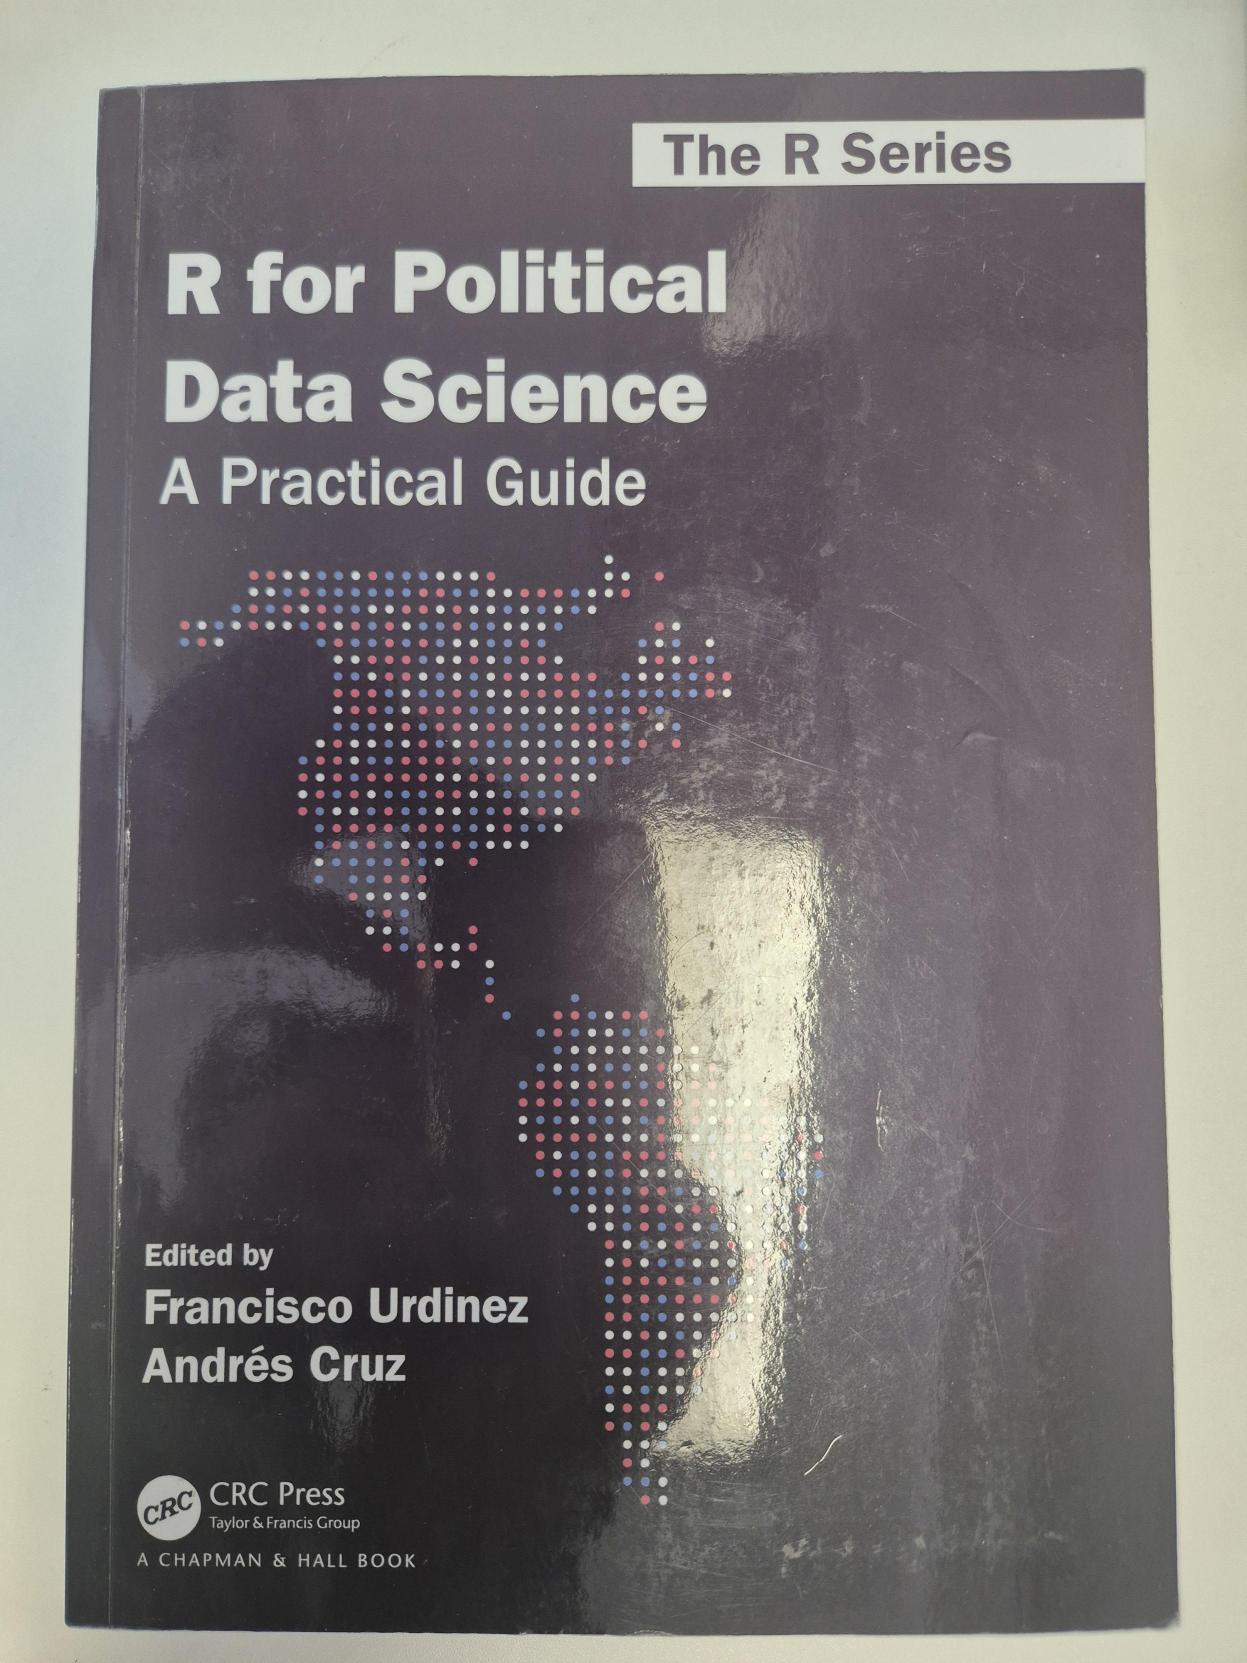

In [9]:
!pip install -q easyocr

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 31.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 13.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 978.2/978.2 kB 50.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 299.6/299.6 kB 17.5 MB/s eta 0:00:00


In [11]:
import easyocr

# let us initialize the reader in English (change based on your needs, if multiple langauges add usig commas)

reader = easyocr.Reader(['en'], gpu=True)
results = reader.readtext('/content/OCR_Test.jpeg')

# to print clean results
for bbox, text, confidence in results:
    print(f"Confidence: {confidence:.2f} | Text: {text}")

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Confidence: 0.95 | Text: The R Series
Confidence: 1.00 | Text: R for Political
Confidence: 0.93 | Text: Data Science
Confidence: 0.99 | Text: A Practical Guide
Confidence: 1.00 | Text: Edited by
Confidence: 0.90 | Text: Francisco Urdinez
Confidence: 0.66 | Text: Andres Cruz
Confidence: 0.96 | Text: CRC Press
Confidence: 0.97 | Text: Taylor & Francis Group
Confidence: 0.55 | Text: A CHAPMAN & HALL Book
Confidence: 0.95 | Text: CRC)


In [13]:
import easyocr

# let us initialize the reader in English (change based on your needs, if multiple langauges add usig commas)

reader = easyocr.Reader(['en', 'es'], gpu=True)
results = reader.readtext('/content/OCR_Test.jpeg')

# to print clean results
for bbox, text, confidence in results:
    print(f"Confidence: {confidence:.2f} | Text: {text}")

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Confidence: 1.00 | Text: The R Series
Confidence: 0.73 | Text: R for Political
Confidence: 0.99 | Text: Data Science
Confidence: 0.73 | Text: A Practical Guide
Confidence: 0.98 | Text: Edited by
Confidence: 1.00 | Text: Francisco Urdinez
Confidence: 0.72 | Text: Andrés Cruz
Confidence: 0.99 | Text: CRC Press
Confidence: 0.92 | Text: Taylor & Francis Group
Confidence: 0.43 | Text: A CHAPMAN & HALL BOoK
Confidence: 0.53 | Text: (CRC)


### Let us look at Messy PDFs

In [15]:
!apt-get install -y poppler-utils
!pip install -q pdf2image easyocr

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
poppler-utils is already the newest version (22.02.0-2ubuntu0.12).
0 upgraded, 0 newly installed, 0 to remove and 3 not upgraded.


In [16]:
import easyocr
reader = easyocr.Reader(['en'], gpu=True)

In [22]:
import os
from pdf2image import convert_from_path


pdf_path = "/content/Pdf_OCRTest.pdf"


# Convert all PDF pages to images at 200 DPI.
pages_as_images = convert_from_path(pdf_path, dpi=200)

print(len(pages_as_images))
print(type(pages_as_images[0]))

2
<class 'PIL.PpmImagePlugin.PpmImageFile'>


In [23]:
pages_as_images

[<PIL.PpmImagePlugin.PpmImageFile image mode=RGB size=1653x2339>,
 <PIL.PpmImagePlugin.PpmImageFile image mode=RGB size=1653x2339>]

In [27]:
import numpy as np

ocr_full_text = ""

# Loop through each page image
for page_num, page_image in enumerate(pages_as_images, start=1):

    # Convert the PIL image object into a NumPy array so EasyOCR can read its pixels
    image_array = np.array(page_image)

    # running the OCR
    page_results = reader.readtext(image_array, paragraph=True)
    ocr_full_text += f"#######################--- PAGE {page_num} ---#################################" # to ensure we know when page ends

    # Extract the text string append it
    for bbox, text in page_results:
        ocr_full_text += text + "\n\n"



In [28]:
ocr_full_text

"#######################--- PAGE 1 ---################################# \n\nThe Scots Magazine: 1 s   B 0 THW E LL C A S T L E , 3as   . ; '  By F MARY   CoLQUHOUN.     . west of Scotland is rich in ruined castles of beauty T[Endeot bisfotlanderesti One of special note is Both - well in Clydesdale, & grand edifice of the thirteenth   century. Most likely it was enlarged during the occupation of the English, and of all the castles of that century may be counted the finest ruin in Scotland.  At that period it was possessed  by the De Moravia, or Moray family. The castle was taken by Edward I, and by lim made over to Aymer de Valence, Earl of Pembroke, governor of that region of Scotland It was in the hands of the English & good deal till 1337 when the Scotch retook and dismantled it The castle then   passed by marriage to the Douglases, and was held by that powerful family tili their forfeiture under   James   IL , 1445. Now it  belongs to the Earl of Home: Bothwell is beautifully situat

## Bonus Task

Congratulations on nearing the end of the data extraction parts!
---

### Task 1: The Invisible Structure (Digital Texts)

Imagine you have successfully extracted raw text from 500 digital PDF research articles. The extraction was clean, but you notice a major roadblock for your downstream analysis:
* Some authors write papers using standard headers like `Introduction`, `Methodology`, and `Conclusion`.
* Other authors use stylized headers like `1. Setting the Stage`, `2. How We Tested This`, or `III. Final Remarks`.

If you need to isolate **only** the text written under the "Methodology/Testing" sections across all 500 papers, how would you design a logical strategy to identify where that section starts and ends?

**Hint:** Think layout metadata which could be extracted from the PDF dictionary format (`span["size"]`, `span["font"]`) and if an LLM could be used? Or any other ideas?

---

### Task 2: The Multi-Page & Column Chaos

When dealing with historical archives, standard horizontal text recognition fails completely because of complex layouts. This can be categorised into 2 major problems:

#### The Double-Page Spread
Old books are often scanned two pages at once onto a single landscape canvas.

What happens to the sentence structure if you pass this raw canvas directly into an OCR engine? How should we be aware of this geometry and what to do about it?|

#### The Multi-Column Bleed
In old newspapers that use tight, 3+ column layouts. Sometimes, the physical paper is aged or faded, meaning the vertical ink lines separating Column 1 from Column 2 are completely invisible to the computer.

If column separators disappear, standard OCR could smash the columns together left-to-right. How can this be detected?

**Hint:** Look for consistently absent characters in specific vertical bands. Anything more creative? Just upload the page to an LLM 👀! Maybe good choice! Could it be?

---

### Task 3: The Target Snippet

Suppose you have video screen-recordings of Instagram profiles. Your task is to extract **only the account username** from the reels section.

What strategy could you use in this case?

**Hint:** Look at region of interest (ROI)